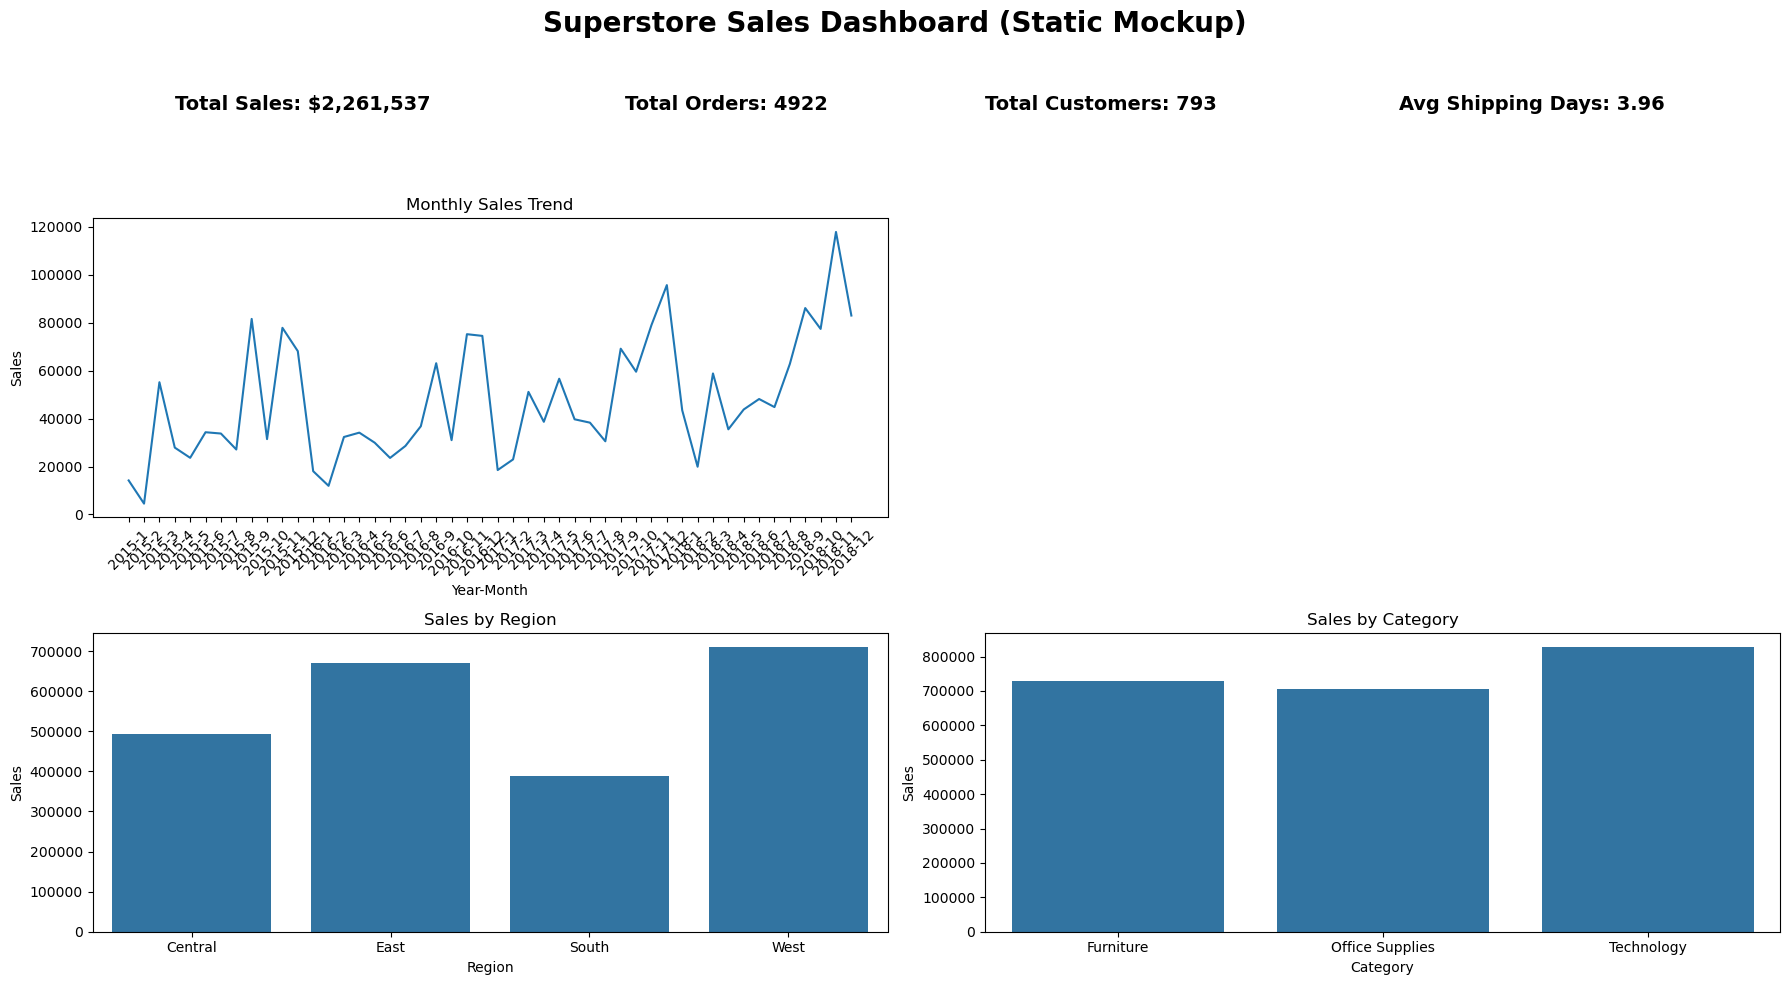

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv("cleaned_data.csv")


# ---------------------------
# KPI Calculations
# ---------------------------
total_sales = df["Sales"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
avg_shipping = df["Shipping Days"].mean()

# Monthly Sales
monthly_sales = df.groupby(["Order Year", "Order Month"])["Sales"].sum().reset_index()
monthly_sales["Year-Month"] = monthly_sales["Order Year"].astype(str) + "-" + monthly_sales["Order Month"].astype(str)

# Sales by Region
region_sales = df.groupby("Region")["Sales"].sum().reset_index()

# Sales by Category
category_sales = df.groupby("Category")["Sales"].sum().reset_index()

# ---------------------------
# Dashboard Layout
# ---------------------------
plt.figure(figsize=(18, 10))

# Title
plt.suptitle("Superstore Sales Dashboard (Static Mockup)", fontsize=20, fontweight='bold')

# KPI Section (Text only)
plt.figtext(0.1, 0.88, f"Total Sales: ${total_sales:,.0f}", fontsize=14, weight='bold')
plt.figtext(0.35, 0.88, f"Total Orders: {total_orders}", fontsize=14, weight='bold')
plt.figtext(0.55, 0.88, f"Total Customers: {total_customers}", fontsize=14, weight='bold')
plt.figtext(0.78, 0.88, f"Avg Shipping Days: {avg_shipping:.2f}", fontsize=14, weight='bold')

# ---------------------------
# Monthly Sales Trend
# ---------------------------
plt.subplot(2, 2, 1)
sns.lineplot(data=monthly_sales, x="Year-Month", y="Sales")
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")

# ---------------------------
# Sales by Region
# ---------------------------
plt.subplot(2, 2, 3)
sns.barplot(data=region_sales, x="Region", y="Sales")
plt.title("Sales by Region")

# ---------------------------
# Sales by Category
# ---------------------------
plt.subplot(2, 2, 4)
sns.barplot(data=category_sales, x="Category", y="Sales")
plt.title("Sales by Category")

plt.tight_layout(rect=[0, 0, 1, 0.85])

# Save Dashboard
plt.savefig("superstore_dashboard_mockup.png", bbox_inches='tight')
plt.show()